In [7]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [2]:
cov_file = './data/roman_real/cov_roman'
cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0])+1)
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i,0])
    jj = int(cov_raw[i,1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element
sigmas = np.diag(cov)

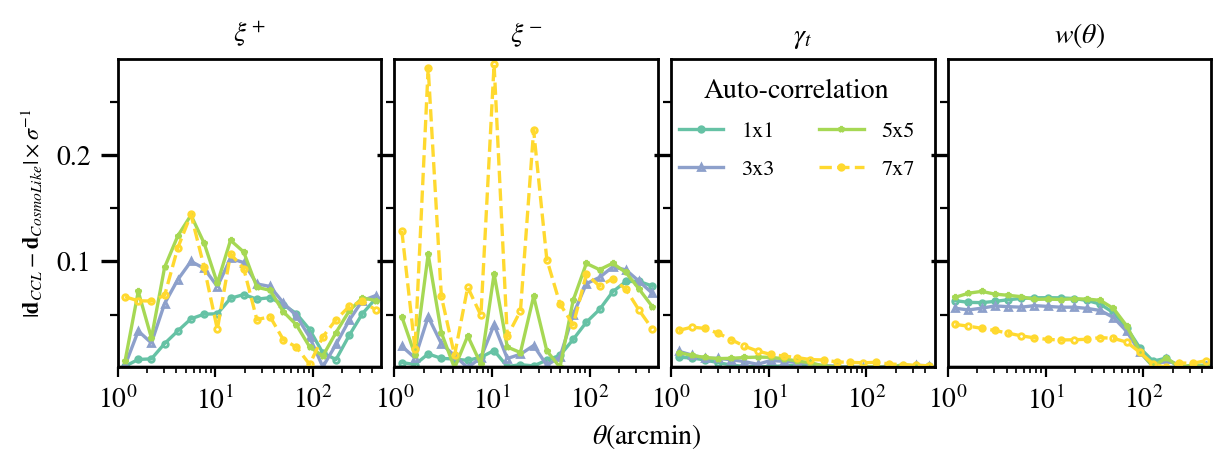

In [6]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import itertools

def make_style_iter():
    linestyles = ['-', '--', '-.', ':']
    #markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    markers = ['o', '^', '*']
    linewidths = [1.2, 2.6]
    return itertools.cycle(itertools.product(linewidths, linestyles, markers, ))


nlens = 10
nsrcs = 5
ntheta=20
tmin = 1
tmax = 500

#thetas used in COCOA
vmin = tmin
vmax = tmax
N = ntheta
logdt = (np.log(vmax) - np.log(vmin))/N
fac = (2./3.)
thetas = []
for i in range(int(N)):
    thetamin = np.exp(np.log(vmin) + (i + 0.)*logdt)
    thetamax = np.exp(np.log(vmin) + (i + 1.)*logdt)
    thetas.append(fac * (thetamax**3 - thetamin**3) / (thetamax**2 - thetamin**2))
thetas = np.array(thetas)

#define plot function
def plot_assemble(axs, cnt, probe, combo, color,ls,mk,lw):
    l,r = int(cnt*ntheta), int(cnt+1)*ntheta
    delta = np.abs(dvF[l:r] - dvC[l:r])/np.sqrt(sigmas[l:r])
    (ln, ) = axs.plot(thetas, delta,markersize=2.0,label=combo,color=color,linestyle=ls,linewidth=lw,marker=mk,markerfacecolor='none')
    axs.axhline(xmin=0,xmax=1,y=0.0,color='k',linestyle='-')
    axs.set_xscale('log')
    return ln

from matplotlib.lines import Line2D

#assemble
fig,ax = plt.subplots(1,4,figsize=(textwidth,2))
plt.subplots_adjust(hspace=0.05)
plt.subplots_adjust(wspace=0.05)
cmap = plt.get_cmap("Set2")
colors = cmap(np.arange(0, nlens)/nlens)

cnt = 0
nlens = 10
nsrcs = 8
ntheta=20
tmin = 1
tmax = 500

dvF_file = './data/roman_real/roman_ccl.modelvector'
dvC_file = './data/roman_real/roman.modelvector'
mask_file = './data/roman_real/roman_Y3.mask'

dvF = np.loadtxt(dvF_file)[:,1]
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1].astype(bool)


cnt = 0
for i in range(len(ax)):
    ax[i].yaxis.set_major_locator(MultipleLocator(0.1))
    ax[i].yaxis.set_minor_locator(MultipleLocator(0.05))
ax[0].set_ylabel(r'$|\mathbf{d}_{CCL}-\mathbf{d}_{CosmoLike}|\times\sigma^{-1}$', fontsize=8)
ax[1].tick_params(axis='y', labelleft=False)
ax[2].tick_params(axis='y', labelleft=False)
ax[3].tick_params(axis='y', labelleft=False)
ax[0].set_xlim(1,499)
ax[1].set_xlim(1,499)
ax[2].set_xlim(1,499)
ax[3].set_xlim(1,499)
ax[0].set_ylim(0.001,0.29)
ax[1].set_ylim(0.001,0.29)
ax[2].set_ylim(0.001,0.29)
ax[3].set_ylim(0.001,0.29)
ax[0].set_title(r'$\xi^+$')
ax[1].set_title(r'$\xi^-$')
ax[2].set_title(r'$\gamma_t$')
ax[3].set_title(r'$w(\theta)$')

#start loop
styles = make_style_iter()
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        if i not in [1,3,5,7]:
            cnt+=1
            continue
        lw,ls,mk = next(styles)
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0], cnt, probe=r'$\xi^+$', combo=f'{i}x{j}',color=cmap(i/nlens),ls=ls,lw=lw,mk=mk)
        cnt+=1
styles = make_style_iter()
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        if i not in [1,3,5,7]:
            cnt+=1
            continue
        lw,ls,mk = next(styles)
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1], cnt, probe=r'$\xi^-$', combo=f'{i}x{j}',color=cmap(i/nlens),ls=ls,lw=lw,mk=mk)
        cnt+=1
styles = make_style_iter()
for i in range(nlens):
    for j in range(nsrcs):
        if i!=j:
            cnt+=1
            continue
        if i not in [1,3,5,7]:
            cnt+=1
            continue
        lw,ls,mk = next(styles)
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[2], cnt, probe=r'$\gamma t$', combo=f'{i}x{j}',color=cmap(i/nlens),ls=ls,lw=lw,mk=mk)
        cnt+=1
styles = make_style_iter()
lines = []
for i in range(nlens):
    if i not in [1,3,5,7]:
        cnt+=1
        continue
    lw,ls,mk = next(styles)
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    ln = plot_assemble(ax[3], cnt, probe=r'$W(\theta)$', combo=f'{i}x{i}',color=cmap(i/nlens),ls=ls,lw=lw,mk=mk)
    lines.append(ln)
    cnt+=1

ax[2].legend(handles=lines, title="Auto-correlation", ncol=2, frameon=False, fontsize=8)
fig.supxlabel(r'$\theta(\mathrm{arcmin})$', fontsize=10,y=-0.1)
plt.savefig('Code_comparison_roman_real.pdf', dpi=300)

In [49]:
print((dvF[mask]-dvC[mask])@np.linalg.pinv(cov[mask,:][:,mask])@(dvF[mask]-dvC[mask]))

1.1046805316888093
